In [44]:
# Importing necessary libraries

import pandas as pd
import duckdb 
import geopandas as gpd
import datetime

In [3]:
# Creating connect

con = duckdb.connect("../01_docs/01_data/project.duckdb")

In [4]:
# Testing connection

con.execute("""
            SELECT *
            FROM read_parquet('../01_docs/01_data/01_raw/fhvhv_tripdata_2024-07.parquet')
            LIMIT 10
            """).df()

,hvfhs_license_num,dispatching_base_num,originating_base_num,request_datetime,on_scene_datetime,pickup_datetime,dropoff_datetime,PULocationID,DOLocationID,trip_miles,...,sales_tax,congestion_surcharge,airport_fee,tips,driver_pay,shared_request_flag,shared_match_flag,access_a_ride_flag,wav_request_flag,wav_match_flag
0,HV0003,B03404,B03404,2024-07-01 00:13:16,2024-07-01 00:18:28,2024-07-01 00:19:43,2024-07-01 00:40:35,138,141,8.840,...,4.70,2.75,2.5,9.28,24.19,N,N,N,N,N
1,HV0003,B03404,B03404,2024-07-01 00:16:44,2024-07-01 00:18:58,2024-07-01 00:21:00,2024-07-01 00:41:24,61,80,3.960,...,2.22,0.00,0.0,0.00,19.37,N,N,N,N,N
2,HV0003,B03404,B03404,2024-07-01 00:38:38,2024-07-01 00:45:10,2024-07-01 00:45:10,2024-07-01 01:01:05,36,260,5.610,...,1.84,0.00,0.0,0.00,12.08,Y,Y,N,N,N
3,HV0003,B03404,B03404,2024-07-01 00:38:26,2024-07-01 00:48:38,2024-07-01 00:49:01,2024-07-01 01:15:02,80,42,11.240,...,4.05,0.00,0.0,0.00,25.64,Y,Y,N,N,N
4,HV0003,B03404,B03404,2024-07-01 00:34:57,2024-07-01 00:40:58,2024-07-01 00:41:36,2024-07-01 00:49:48,152,41,1.600,...,1.03,0.00,0.0,5.00,7.11,N,N,N,N,N
5,HV0005,B03406,NaN,2024-07-01 00:36:16,NaT,2024-07-01 00:44:05,2024-07-01 00:54:37,138,92,3.343,...,1.93,0.00,2.5,0.00,11.45,N,N,N,N,N
6,HV0003,B03404,B03404,2024-07-01 00:05:41,2024-07-01 00:09:27,2024-07-01 00:09:49,2024-07-01 00:35:52,164,17,5.520,...,3.27,2.75,0.0,0.00,25.95,N,N,N,N,N
7,HV0003,B03404,B03404,2024-07-01 00:36:11,2024-07-01 00:40:27,2024-07-01 00:41:13,2024-07-01 00:49:39,37,225,1.680,...,1.19,0.00,0.0,0.00,8.19,N,N,N,N,N
8,HV0003,B03404,B03404,2024-07-01 00:48:32,2024-07-01 00:50:15,2024-07-01 00:51:13,2024-07-01 01:21:50,225,79,6.860,...,1.55,0.75,0.0,0.00,16.04,Y,Y,N,N,N
9,HV0003,B03404,B03404,2024-07-01 00:47:59,2024-07-01 00:52:47,2024-07-01 00:53:03,2024-07-01 01:01:39,17,49,1.370,...,0.43,0.00,0.0,0.00,2.95,Y,Y,N,N,N


In [5]:
# Creating views for each category of trip data

def create_view(con, category):
    con.execute(f"""
                CREATE OR REPLACE VIEW {category} AS
                SELECT *
                FROM read_parquet('../01_docs/01_data/01_raw/{category}_tripdata_2024-**.parquet')
                """)


create_view(con, 'fhvhv')

create_view(con, 'fhv')

create_view(con, 'green')

create_view(con, 'yellow')

In [6]:
# Checking features of the created views

con.execute("DESCRIBE fhvhv").df()

,column_name,column_type,null,key,default,extra
0,hvfhs_license_num,VARCHAR,YES,None,None,None
1,dispatching_base_num,VARCHAR,YES,None,None,None
2,originating_base_num,VARCHAR,YES,None,None,None
3,request_datetime,TIMESTAMP,YES,None,None,None
4,on_scene_datetime,TIMESTAMP,YES,None,None,None
5,pickup_datetime,TIMESTAMP,YES,None,None,None
6,dropoff_datetime,TIMESTAMP,YES,None,None,None
7,PULocationID,INTEGER,YES,None,None,None
8,DOLocationID,INTEGER,YES,None,None,None
9,trip_miles,DOUBLE,YES,None,None,None


In [7]:
con.execute("DESCRIBE fhv").df()

,column_name,column_type,null,key,default,extra
0,dispatching_base_num,VARCHAR,YES,None,None,None
1,pickup_datetime,TIMESTAMP,YES,None,None,None
2,dropOff_datetime,TIMESTAMP,YES,None,None,None
3,PUlocationID,BIGINT,YES,None,None,None
4,DOlocationID,BIGINT,YES,None,None,None
5,SR_Flag,BIGINT,YES,None,None,None
6,Affiliated_base_number,VARCHAR,YES,None,None,None


In [8]:
con.execute("DESCRIBE green").df()

,column_name,column_type,null,key,default,extra
0,VendorID,INTEGER,YES,None,None,None
1,lpep_pickup_datetime,TIMESTAMP,YES,None,None,None
2,lpep_dropoff_datetime,TIMESTAMP,YES,None,None,None
3,store_and_fwd_flag,VARCHAR,YES,None,None,None
4,RatecodeID,BIGINT,YES,None,None,None
5,PULocationID,INTEGER,YES,None,None,None
6,DOLocationID,INTEGER,YES,None,None,None
7,passenger_count,BIGINT,YES,None,None,None
8,trip_distance,DOUBLE,YES,None,None,None
9,fare_amount,DOUBLE,YES,None,None,None


In [9]:
con.execute("DESCRIBE yellow").df()

,column_name,column_type,null,key,default,extra
0,VendorID,INTEGER,YES,None,None,None
1,tpep_pickup_datetime,TIMESTAMP,YES,None,None,None
2,tpep_dropoff_datetime,TIMESTAMP,YES,None,None,None
3,passenger_count,BIGINT,YES,None,None,None
4,trip_distance,DOUBLE,YES,None,None,None
5,RatecodeID,BIGINT,YES,None,None,None
6,store_and_fwd_flag,VARCHAR,YES,None,None,None
7,PULocationID,INTEGER,YES,None,None,None
8,DOLocationID,INTEGER,YES,None,None,None
9,payment_type,BIGINT,YES,None,None,None


In [10]:
# Creating views with selected features

def create_view_selected(con, category, selected_features=["pickup_datetime", "PULocationID"]):
    con.execute(f"""
                CREATE OR REPLACE VIEW {category}_selected AS
                SELECT
                {selected_features[0]} AS pickup_datetime,
                {selected_features[1]} AS pickup_location
                FROM {category}
                """)

create_view_selected(con, 'fhvhv')
create_view_selected(con, 'fhv')
create_view_selected(con, 'green', selected_features=["lpep_pickup_datetime", "PULocationID"])
create_view_selected(con, 'yellow', selected_features=["tpep_pickup_datetime", "PULocationID"])

In [11]:
# Checking for missing values

con.execute("""
            SELECT COUNT(*) FROM fhvhv_selected WHERE pickup_datetime IS NULL OR pickup_location IS NULL
            UNION ALL
            SELECT COUNT(*) FROM fhv_selected WHERE pickup_datetime IS NULL OR pickup_location IS NULL
            UNION ALL
            SELECT COUNT(*) FROM green_selected WHERE pickup_datetime IS NULL OR pickup_location IS NULL
            UNION ALL
            SELECT COUNT(*) FROM yellow_selected WHERE pickup_datetime IS NULL OR pickup_location IS NULL
            """).df()

,count_star()
0,0
1,14015589
2,0
3,0


In [12]:
con.execute("""
            SELECT COUNT(*) FROM fhv_selected WHERE pickup_datetime IS NULL
            UNION ALL
            SELECT COUNT(*) FROM fhv_selected WHERE pickup_location IS NULL
            """).df()

,count_star()
0,0
1,14015589


In [13]:
con.execute("SELECT COUNT(*) FROM fhv_selected").df()

,count_star()
0,17630326


In [14]:
# Filtering missing values 

con.execute("""CREATE OR REPLACE VIEW fhv_filtered AS 
            SELECT * FROM fhv_selected WHERE pickup_location IS NOT NULL""")

In [15]:
con.execute("SELECT COUNT(*) FROM fhv_filtered WHERE pickup_datetime IS NULL OR pickup_location IS NULL").df()

,count_star()
0,0


In [16]:
# Combining the selected views into a single view

con.execute("""
            CREATE OR REPLACE VIEW combined_trips AS
            SELECT * FROM fhvhv_selected
            UNION ALL
            SELECT * FROM fhv_filtered
            UNION ALL
            SELECT * FROM green_selected
            UNION ALL
            SELECT * FROM yellow_selected
            """)

In [17]:
# Checking for size of the created view

con.execute("""
            SELECT COUNT(*) AS total_rows
            FROM combined_trips
            """).df()

,total_rows
0,284915123


In [18]:
# Checking features of the created view

con.execute("DESCRIBE combined_trips").df()

,column_name,column_type,null,key,default,extra
0,pickup_datetime,TIMESTAMP,YES,None,None,None
1,pickup_location,BIGINT,YES,None,None,None


In [19]:
# Calculating total rides per location and timestamp 

time_interval = '15 minutes'

con.execute(f"""
            CREATE OR REPLACE VIEW total_rides_per_location_and_time AS
            SELECT
            pickup_location,
            time_stamp,
            COUNT(*) AS total_rides

            FROM (
                SELECT 
                    pickup_location, 
                    CAST(TIME_BUCKET(INTERVAL {time_interval}, CAST(pickup_datetime AS TIMESTAMP)) AS TIME) AS time_stamp 
                FROM combined_trips
            )t
            GROUP BY pickup_location, time_stamp
            ORDER BY time_stamp, pickup_location;""")

In [20]:
# Checking the created view with timestamp

con.execute("SELECT * FROM total_rides_per_location_and_time LIMIT 10").df()

,pickup_location,time_stamp,total_rides
0,1,00:00:00,161
1,2,00:00:00,2
2,3,00:00:00,3756
3,4,00:00:00,11744
4,5,00:00:00,374
5,6,00:00:00,803
6,7,00:00:00,24703
7,8,00:00:00,54
8,9,00:00:00,1413
9,10,00:00:00,5315


In [21]:
con.execute("DESCRIBE total_rides_per_location_and_time").df()

,column_name,column_type,null,key,default,extra
0,pickup_location,BIGINT,YES,None,None,None
1,time_stamp,TIME,YES,None,None,None
2,total_rides,BIGINT,YES,None,None,None


In [22]:
con.execute("""SELECT COUNT(*) AS total_rows FROM total_rides_per_location_and_time""").df()

,total_rows
0,25130


In [23]:
24*60/15*265

25440.0

In [24]:
# Importing the location lookup data

zones = gpd.read_file("../01_docs/03_guides/taxi_zones_shapefiles/taxi_zones.shp")

<Axes: >

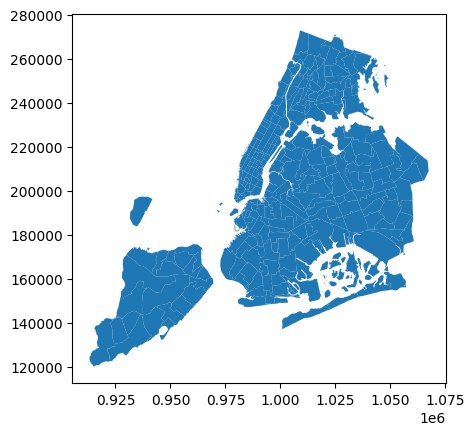

In [25]:
# Checking the imported zones

zones.plot()

In [27]:
# Merging the total rides data with the location lookup data

trip_data = con.execute("""SELECT * FROM total_rides_per_location_and_time""").df()

trip_data_with_zones = zones.merge(trip_data, left_on='LocationID', right_on='pickup_location', how='left')

In [ ]:
# Checking for missing values in the merged data

trip_data_with_zones.isna().sum()

# Missing values can be detected after visualization and be threated accordingly

OBJECTID           0
Shape_Leng         0
Shape_Area         0
zone               0
LocationID         0
borough            0
geometry           0
pickup_location    2
time_stamp         2
total_rides        2
dtype: int64

<Axes: >

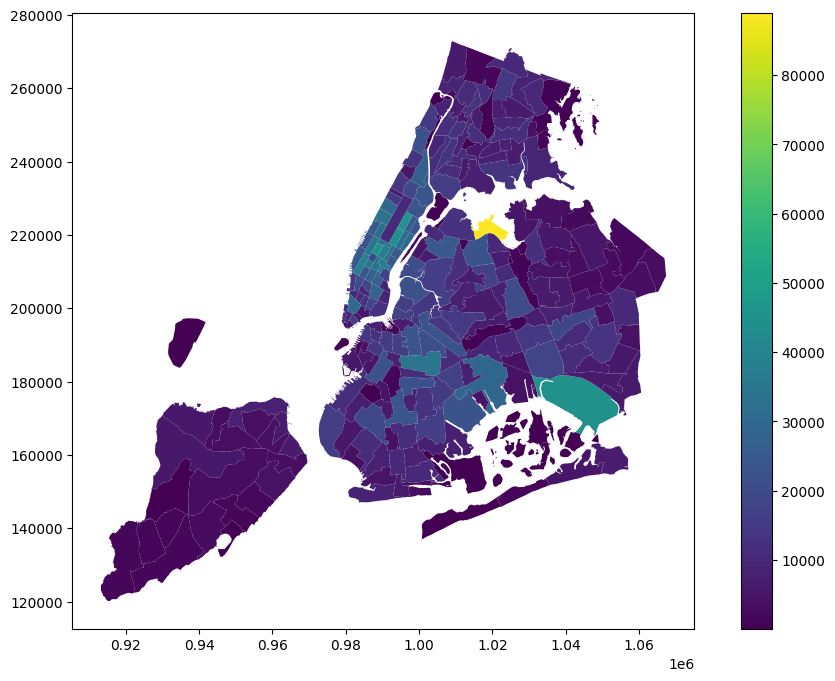

In [50]:
trip_data_with_zones[trip_data_with_zones['time_stamp'] == datetime.time(10, 0)].plot(column='total_rides', legend=True, figsize=(12, 8))

In [52]:
# Saving the merged data

trip_data_with_zones.to_file("../01_docs/01_data/02_processed/trip_data_with_zones.gpkg")